# Fase 7 — eICU Cohorte y Etiqueta L2

Construcción de la cohorte de validación externa a partir de eICU-CRD v2.0.

**Criterio de inclusión:** `unitadmitsource == 'Emergency Department'` (cohorte estricta — solo pacientes procedentes de urgencias, equivalente funcional al origen de la cohorte MIMIC-IV-ED).

**Etiqueta L2:** `hospitaldischargestatus == 'Expired'` (mortalidad hospitalaria).

**L1 no evaluable:** todos los pacientes de eICU ya están ingresados en UCI en el momento del registro, lo que hace la etiqueta trivialmente positiva.

In [1]:
import logging, sys
from pathlib import Path

_root = Path.cwd()
while not (_root / 'CLAUDE.md').exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

logging.basicConfig(level=logging.INFO, format='%(levelname)s — %(message)s', force=True)
print(f'Raíz del proyecto: {_root}')

Raíz del proyecto: C:\Users\cuent\Documents\UAX\TFM\TFM


In [2]:
import pandas as pd

EICU = _root / 'data/eicu-collaborative-research-database-2.0'
OUT  = _root / 'data/processed'
OUT.mkdir(exist_ok=True)

## 1. Carga de patient.csv

Tabla principal de eICU-CRD con una fila por estancia en UCI (`patientunitstayid`). Contiene variables demográficas, fuente de ingreso a UCI, tipo de unidad y estado al alta hospitalaria.

In [3]:
pt = pd.read_csv(EICU / 'patient.csv')
print(f'Total estancias eICU: {len(pt):,}')
print(f'Columnas: {pt.columns.tolist()}')
pt.head(3)

Total estancias eICU: 200,859
Columnas: ['patientunitstayid', 'patienthealthsystemstayid', 'gender', 'age', 'ethnicity', 'hospitalid', 'wardid', 'apacheadmissiondx', 'admissionheight', 'hospitaladmittime24', 'hospitaladmitoffset', 'hospitaladmitsource', 'hospitaldischargeyear', 'hospitaldischargetime24', 'hospitaldischargeoffset', 'hospitaldischargelocation', 'hospitaldischargestatus', 'unittype', 'unitadmittime24', 'unitadmitsource', 'unitvisitnumber', 'unitstaytype', 'admissionweight', 'dischargeweight', 'unitdischargetime24', 'unitdischargeoffset', 'unitdischargelocation', 'unitdischargestatus', 'uniquepid']


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
0,141168,128919,Female,70,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",152.4,15:54:00,...,Direct Admit,1,admit,84.3,85.8,03:50:00,3596,Death,Expired,002-34851
1,141178,128927,Female,52,Caucasian,60,83,NaN,162.6,08:56:00,...,Emergency Department,1,admit,54.4,54.4,09:18:00,8,Step-Down Unit (SDU),Alive,002-33870
2,141179,128927,Female,52,Caucasian,60,83,NaN,162.6,08:56:00,...,ICU to SDU,2,stepdown/other,NaN,60.4,19:20:00,2042,Home,Alive,002-33870


## 2. Distribución de `unitadmitsource`

Frecuencias de la variable de origen de ingreso a UCI. Se usa para verificar el volumen de pacientes procedentes de urgencias antes de aplicar el filtro de cohorte.

In [4]:
print('unitadmitsource:')
print(pt['unitadmitsource'].value_counts().to_string())

unitadmitsource:
unitadmitsource
Emergency Department    89594
Floor                   24368
Operating Room          24305
ICU to SDU              13827
Direct Admit            12672
Recovery Room            7844
Acute Care/Floor         5604
Step-Down Unit (SDU)     5450
ICU                      5439
Other Hospital           4323
Other ICU                4264
PACU                     1714
Chest Pain Center         336
Observation                19
Other                      10


## 3. Filtro de cohorte: solo pacientes desde Urgencias

Criterio de inclusión: `unitadmitsource == 'Emergency Department'`. Este filtro garantiza la equivalencia funcional con la cohorte MIMIC-IV-ED, donde todos los pacientes provienen del servicio de urgencias.

In [5]:
cohort = pt[pt['unitadmitsource'] == 'Emergency Department'].copy()
print(f'Admitidos desde ED: {len(cohort):,} ({len(cohort)/len(pt):.1%} del total)')

Admitidos desde ED: 89,594 (44.6% del total)


## 4. Etiqueta L2 (mortalidad hospitalaria)

In [6]:
cohort['L2'] = (cohort['hospitaldischargestatus'] == 'Expired').astype(int)
print(f'L2 positivos: {cohort["L2"].sum():,} ({cohort["L2"].mean():.3%})')
print()
print('hospitaldischargestatus:')
print(cohort['hospitaldischargestatus'].value_counts())

L2 positivos: 7,687 (8.580%)

hospitaldischargestatus:
hospitaldischargestatus
Alive      81044
Expired     7687
Name: count, dtype: int64


## 5. Conversión de edad (string → numérico)

Edad media: 61.8 anos
Missing:    0.0%


<Axes: >

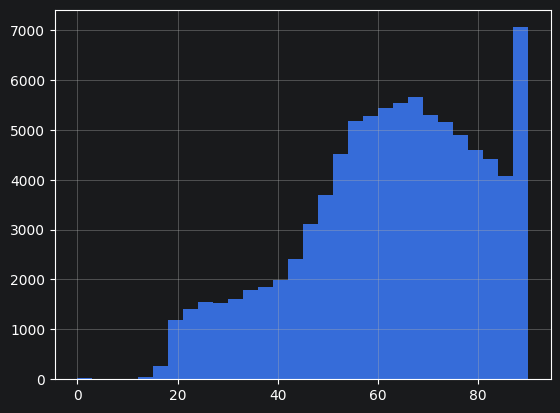

In [7]:
def parse_age(a):
    if pd.isna(a):
        return float('nan')
    s = str(a).strip()
    # eICU codifica "> 89" como string para pacientes > 89 años (anonimización)
    if s == '> 89':
        return 90.0
    try:
        return float(s)
    except ValueError:
        return float('nan')

cohort['age_num'] = cohort['age'].apply(parse_age)
print(f'Edad media: {cohort["age_num"].mean():.1f} anos')
print(f'Missing:    {cohort["age_num"].isna().mean():.1%}')
cohort['age_num'].hist(bins=30)

## 6. Estadísticas demográficas

Distribución de género, etnia y tipo de UCI en la cohorte filtrada. Sirve como verificación de la representatividad demográfica y para documentar diferencias con la cohorte MIMIC-IV-ED en el apartado de validación externa del manuscrito.

In [8]:
print('Gender:')
print(cohort['gender'].value_counts())
print()
print('Ethnicity (top 10):')
print(cohort['ethnicity'].value_counts().head(10))
print()
print('unittype (top 5):')
print(cohort['unittype'].value_counts().head(5))

Gender:
gender
Male       47571
Female     41945
Unknown       29
Other          7
Name: count, dtype: int64

Ethnicity (top 10):
ethnicity
Caucasian           67383
African American    11008
Other/Unknown        4263
Hispanic             3682
Asian                1531
Native American       656
Name: count, dtype: int64

unittype (top 5):
unittype
Med-Surg ICU    55656
MICU             8674
Cardiac ICU      6392
CCU-CTICU        6141
Neuro ICU        5877
Name: count, dtype: int64


## 7. Guardar cohorte

Se serializa la cohorte eICU filtrada en `data/processed/eicu_cohort.parquet` con las columnas necesarias para el pipeline de inferencia (vitales, etiquetas, variables demográficas).

In [9]:
keep = [
    'patientunitstayid', 'patienthealthsystemstayid',
    'gender', 'age', 'age_num', 'ethnicity',
    'hospitalid', 'unittype',
    'hospitaladmitoffset', 'unitdischargeoffset',
    'hospitaldischargestatus', 'L2',
]
cohort = cohort[keep].reset_index(drop=True)
cohort.to_parquet(OUT / 'eicu_cohort.parquet', index=False)
print(f'Guardado: eicu_cohort.parquet — shape {cohort.shape}')
cohort.head()

Guardado: eicu_cohort.parquet — shape (89594, 12)


,patientunitstayid,patienthealthsystemstayid,gender,age,age_num,ethnicity,hospitalid,unittype,hospitaladmitoffset,unitdischargeoffset,hospitaldischargestatus,L2
0,141178,128927,Female,52,52.0,Caucasian,60,Med-Surg ICU,-14,8,Alive,0
1,141197,128943,Male,71,71.0,Caucasian,67,Med-Surg ICU,-25,74,Alive,0
2,141208,128952,Female,25,25.0,Caucasian,73,Med-Surg ICU,-1,720,Alive,0
3,141229,128970,Female,> 89,90.0,Caucasian,63,Med-Surg ICU,-4,166,Alive,0
4,141260,128995,Female,43,43.0,African American,73,Med-Surg ICU,-18,1073,Alive,0
